# Social-media-only models -- predicting daily change in Polymarket Trump probability

Three models using Bluesky and Reddit social media features:
1. Linear Regression
2. Random Forest
3. Neural Network (MLP)

**Target:** daily change in `polymarket_trump_prob`  
**Features:** 39 Bluesky + Reddit columns (same-day)  
**Splits/Metrics:** same methodology as `1_lag.ipynb`

<!-- toc -->
## Contents
- [1. Setup](#1-setup)
- [2. Load data & compute target](#2-load-data-compute-target)
- [3. Train/val/test split](#3-trainvaltest-split)
- [4. CV folds](#4-cv-folds)
- [5. Helper functions](#5-helper-functions)
- [6. Model 1 -- Linear Regression](#6-model-1----linear-regression)
- [7. Model 2 -- Random Forest](#7-model-2----random-forest)
- [8. Model 3 -- Neural Network (MLP)](#8-model-3----neural-network-mlp)
- [9. Model comparison](#9-model-comparison)


## 1. Setup

In [1]:
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

sys.path.insert(0, "../../")
from Functions.data_splits import get_cv_folds, get_test_split, print_fold_summary, validate_no_leakage

RANDOM_STATE = 42
TEST_DAYS    = 14
N_SPLITS     = 3
GAP          = 1

SOCIAL_COLS = [
    "bsky_post_count", "bsky_trump_post_share", "bsky_reply_ratio", "bsky_repost_ratio",
    "bsky_trump_sentiment_avg", "bsky_harris_sentiment_avg",
    "bsky_trump_sent_std", "bsky_harris_sent_std",
    "bsky_trump_strong_pos_ratio", "bsky_harris_strong_pos_ratio",
    "bsky_trump_strong_neg_ratio", "bsky_harris_strong_neg_ratio",
    "bsky_sentiment_velocity",
    "net_density", "net_trump_hub_degree_avg", "net_community_homophily",
    "net_bridge_post_share", "echo_chamber_velocity", "net_modularity_Q",
    "reddit_post_count", "reddit_trump_post_share", "reddit_harris_post_share",
    "reddit_trump_upvote_ratio", "reddit_comment_count",
    "reddit_conservative_activity", "reddit_cross_sub_ratio",
    "reddit_trump_sentiment_avg", "reddit_trump_sent_std",
    "reddit_trump_strong_pos_ratio", "reddit_trump_strong_neg_ratio",
    "reddit_trump_n_texts",
    "reddit_harris_sentiment_avg", "reddit_harris_sent_std",
    "reddit_harris_strong_pos_ratio", "reddit_harris_strong_neg_ratio",
    "reddit_harris_n_texts",
    "reddit_sentiment_gap", "reddit_sentiment_platform_gap",
]

## 2. Load data & compute target

In [2]:
df_raw = pd.read_csv("../../Data/3_Gold/basetable.csv", parse_dates=["date"])
df_raw = df_raw.sort_values("date").reset_index(drop=True)

df = df_raw[["date", "polymarket_trump_prob"] + SOCIAL_COLS].copy()
df["target"] = df["polymarket_trump_prob"].diff()
df = df.dropna().reset_index(drop=True)

print(f"Features: {len(SOCIAL_COLS)}")
print(f"Clean rows: {len(df)}  ({df['date'].min().date()} to {df['date'].max().date()})")
print("\nTarget stats:")
print(df["target"].describe().round(4))

Features: 38
Clean rows: 112  (2024-07-07 to 2024-11-03)

Target stats:
count    112.0000
mean      -0.0002
std        0.0178
min       -0.0600
25%       -0.0100
50%       -0.0003
75%        0.0090
max        0.0800
Name: target, dtype: float64


## 3. Train/val/test split

In [3]:
tv_idx, test_idx = get_test_split(df, test_days=TEST_DAYS)

df_tv   = df.iloc[tv_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)

X_tv   = df_tv[SOCIAL_COLS].values
y_tv   = df_tv["target"].values
X_test = df_test[SOCIAL_COLS].values
y_test = df_test["target"].values

print(f"Train/val : {len(df_tv):>4} rows  ({df_tv['date'].min().date()} to {df_tv['date'].max().date()})")
print(f"Test      : {len(df_test):>4} rows  ({df_test['date'].min().date()} to {df_test['date'].max().date()})")

Train/val :   98 rows  (2024-07-07 to 2024-10-20)
Test      :   14 rows  (2024-10-21 to 2024-11-03)


## 4. CV folds

In [4]:
folds = get_cv_folds(df_tv, n_splits=N_SPLITS, gap=GAP, test_days=None)
print_fold_summary(df_tv, folds)

print("\nLeakage validation:")
for i, (tr, va) in enumerate(folds, 1):
    validate_no_leakage(tr, va, df_tv, gap=GAP)
    print(f"  Fold {i}: OK")

Fold   Train start     Train end   #Train     Val start       Val end    #Val
-----------------------------------------------------------------------------
   1    2024-07-07    2024-08-07       25    2024-08-09    2024-09-01      24
   2    2024-07-07    2024-08-31       49    2024-09-02    2024-09-26      24
   3    2024-07-07    2024-09-25       73    2024-09-27    2024-10-20      24

Leakage validation:
  Fold 1: OK
  Fold 2: OK
  Fold 3: OK


## 5. Helper functions

In [5]:
def directional_accuracy(y_true, y_pred):
    return float(np.mean(np.sign(y_true) == np.sign(y_pred)))


def compute_metrics(y_true, y_pred):
    return {
        "MAE"          : mean_absolute_error(y_true, y_pred),
        "RMSE"         : np.sqrt(mean_squared_error(y_true, y_pred)),
        "Dir. Accuracy": directional_accuracy(y_true, y_pred),
        "R2"           : r2_score(y_true, y_pred),
    }


def cv_evaluate(model_factory, folds, X, y, scale=False):
    records = []
    for i, (train_idx, val_idx) in enumerate(folds, 1):
        X_tr, y_tr   = X[train_idx], y[train_idx]
        X_val, y_val = X[val_idx],   y[val_idx]
        if scale:
            sc = StandardScaler()
            X_tr  = sc.fit_transform(X_tr)
            X_val = sc.transform(X_val)
        model = model_factory()
        model.fit(X_tr, y_tr)
        m = compute_metrics(y_val, model.predict(X_val))
        records.append({"Fold": i, **m})
        print(f"  Fold {i}: MAE={m['MAE']:.4f}  RMSE={m['RMSE']:.4f}  DA={m['Dir. Accuracy']:.3f}  R2={m['R2']:.4f}")
    agg  = pd.DataFrame(records).set_index("Fold")
    mean = agg.mean().rename("Mean")
    std  = agg.std().rename("Std")
    print(f"  -- Mean --  MAE={mean['MAE']:.4f}  RMSE={mean['RMSE']:.4f}  DA={mean['Dir. Accuracy']:.3f}  R2={mean['R2']:.4f}")
    return pd.concat([agg, mean.to_frame().T, std.to_frame().T])


def final_eval(model_factory, X_tv, y_tv, X_test, y_test, scale=False):
    if scale:
        sc = StandardScaler()
        X_tv_s   = sc.fit_transform(X_tv)
        X_test_s = sc.transform(X_test)
    else:
        X_tv_s, X_test_s = X_tv, X_test
    model = model_factory()
    model.fit(X_tv_s, y_tv)
    y_pred = model.predict(X_test_s)
    return model, y_pred, compute_metrics(y_test, y_pred)

## 6. Model 1 -- Linear Regression

In [6]:
print("=== Linear Regression -- CV ===")
lr_cv = cv_evaluate(LinearRegression, folds, X_tv, y_tv, scale=True)
lr_cv.round(4)

=== Linear Regression -- CV ===
  Fold 1: MAE=0.0679  RMSE=0.1030  DA=0.333  R2=-86.0524
  Fold 2: MAE=0.0292  RMSE=0.0337  DA=0.292  R2=-12.6564
  Fold 3: MAE=0.0168  RMSE=0.0216  DA=0.625  R2=-1.1042
  -- Mean --  MAE=0.0379  RMSE=0.0528  DA=0.417  R2=-33.2710


,MAE,RMSE,Dir. Accuracy,R2
1,0.0679,0.1030,0.3333,-86.0524
2,0.0292,0.0337,0.2917,-12.6564
3,0.0168,0.0216,0.6250,-1.1042
Mean,0.0379,0.0528,0.4167,-33.2710
Std,0.0267,0.0439,0.1816,46.0735


In [7]:
lr_model, lr_pred, lr_test = final_eval(LinearRegression, X_tv, y_tv, X_test, y_test, scale=True)
print("Linear Regression -- Test set:")
for k, v in lr_test.items():
    print(f"  {k}: {v:.4f}")

Linear Regression -- Test set:
  MAE: 0.0179
  RMSE: 0.0241
  Dir. Accuracy: 0.5714
  R2: -0.4172


## 7. Model 2 -- Random Forest

In [8]:
rf_factory = lambda: RandomForestRegressor(
    n_estimators=200, max_depth=4, min_samples_leaf=3,
    random_state=RANDOM_STATE, n_jobs=-1,
)

print("=== Random Forest -- CV ===")
rf_cv = cv_evaluate(rf_factory, folds, X_tv, y_tv, scale=False)
rf_cv.round(4)

=== Random Forest -- CV ===
  Fold 1: MAE=0.0128  RMSE=0.0162  DA=0.458  R2=-1.1473
  Fold 2: MAE=0.0066  RMSE=0.0081  DA=0.625  R2=0.2041
  Fold 3: MAE=0.0116  RMSE=0.0151  DA=0.542  R2=-0.0310
  -- Mean --  MAE=0.0103  RMSE=0.0131  DA=0.542  R2=-0.3247


,MAE,RMSE,Dir. Accuracy,R2
1,0.0128,0.0162,0.4583,-1.1473
2,0.0066,0.0081,0.6250,0.2041
3,0.0116,0.0151,0.5417,-0.0310
Mean,0.0103,0.0131,0.5417,-0.3247
Std,0.0033,0.0044,0.0833,0.7220


In [9]:
rf_model, rf_pred, rf_test = final_eval(rf_factory, X_tv, y_tv, X_test, y_test, scale=False)
print("Random Forest -- Test set:")
for k, v in rf_test.items():
    print(f"  {k}: {v:.4f}")

Random Forest -- Test set:
  MAE: 0.0164
  RMSE: 0.0225
  Dir. Accuracy: 0.6429
  R2: -0.2393


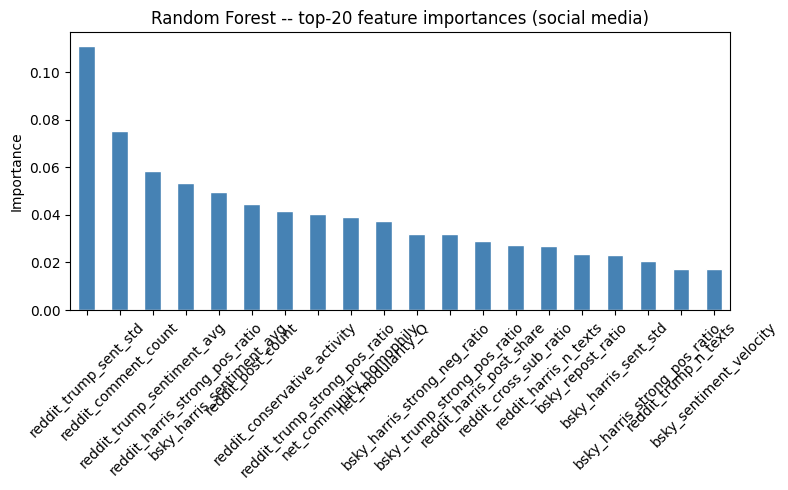

In [10]:
fi = pd.Series(rf_model.feature_importances_, index=SOCIAL_COLS).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
fi.head(20).plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Random Forest -- top-20 feature importances (social media)")
ax.set_ylabel("Importance")
ax.tick_params(axis="x", labelrotation=45)
plt.tight_layout()
plt.show()

## 8. Model 3 -- Neural Network (MLP)

In [11]:
nn_factory = lambda: MLPRegressor(
    hidden_layer_sizes=(32, 16), activation="relu", solver="adam",
    learning_rate_init=1e-3, max_iter=1000,
    early_stopping=True, validation_fraction=0.15,
    n_iter_no_change=30, random_state=RANDOM_STATE,
)

print("=== Neural Network (MLP) -- CV ===")
nn_cv = cv_evaluate(nn_factory, folds, X_tv, y_tv, scale=True)
nn_cv.round(4)

=== Neural Network (MLP) -- CV ===
  Fold 1: MAE=0.3321  RMSE=0.4584  DA=0.458  R2=-1723.6543
  Fold 2: MAE=0.2389  RMSE=0.3422  DA=0.458  R2=-1403.5843
  Fold 3: MAE=0.1019  RMSE=0.1370  DA=0.708  R2=-83.7988
  -- Mean --  MAE=0.2243  RMSE=0.3125  DA=0.542  R2=-1070.3458


,MAE,RMSE,Dir. Accuracy,R2
1,0.3321,0.4584,0.4583,-1723.6543
2,0.2389,0.3422,0.4583,-1403.5843
3,0.1019,0.1370,0.7083,-83.7988
Mean,0.2243,0.3125,0.5417,-1070.3458
Std,0.1158,0.1628,0.1443,869.2338


In [12]:
nn_model, nn_pred, nn_test = final_eval(nn_factory, X_tv, y_tv, X_test, y_test, scale=True)
print("Neural Network -- Test set:")
for k, v in nn_test.items():
    print(f"  {k}: {v:.4f}")

Neural Network -- Test set:
  MAE: 0.1122
  RMSE: 0.1498
  Dir. Accuracy: 0.4286
  R2: -53.9101


## 9. Model comparison

In [13]:
cv_summary = pd.DataFrame({
    "Linear Regression": lr_cv.loc["Mean"],
    "Random Forest"    : rf_cv.loc["Mean"],
    "Neural Network"   : nn_cv.loc["Mean"],
}).T.round(4)
print("CV performance (mean across folds):")
display(cv_summary)

CV performance (mean across folds):


,MAE,RMSE,Dir. Accuracy,R2
Linear Regression,0.0379,0.0528,0.4167,-33.2710
Random Forest,0.0103,0.0131,0.5417,-0.3247
Neural Network,0.2243,0.3125,0.5417,-1070.3458


In [14]:
test_summary = pd.DataFrame({
    "Linear Regression": lr_test,
    "Random Forest"    : rf_test,
    "Neural Network"   : nn_test,
}).T.round(4)
print("Test set performance:")
display(test_summary)

Test set performance:


,MAE,RMSE,Dir. Accuracy,R2
Linear Regression,0.0179,0.0241,0.5714,-0.4172
Random Forest,0.0164,0.0225,0.6429,-0.2393
Neural Network,0.1122,0.1498,0.4286,-53.9101


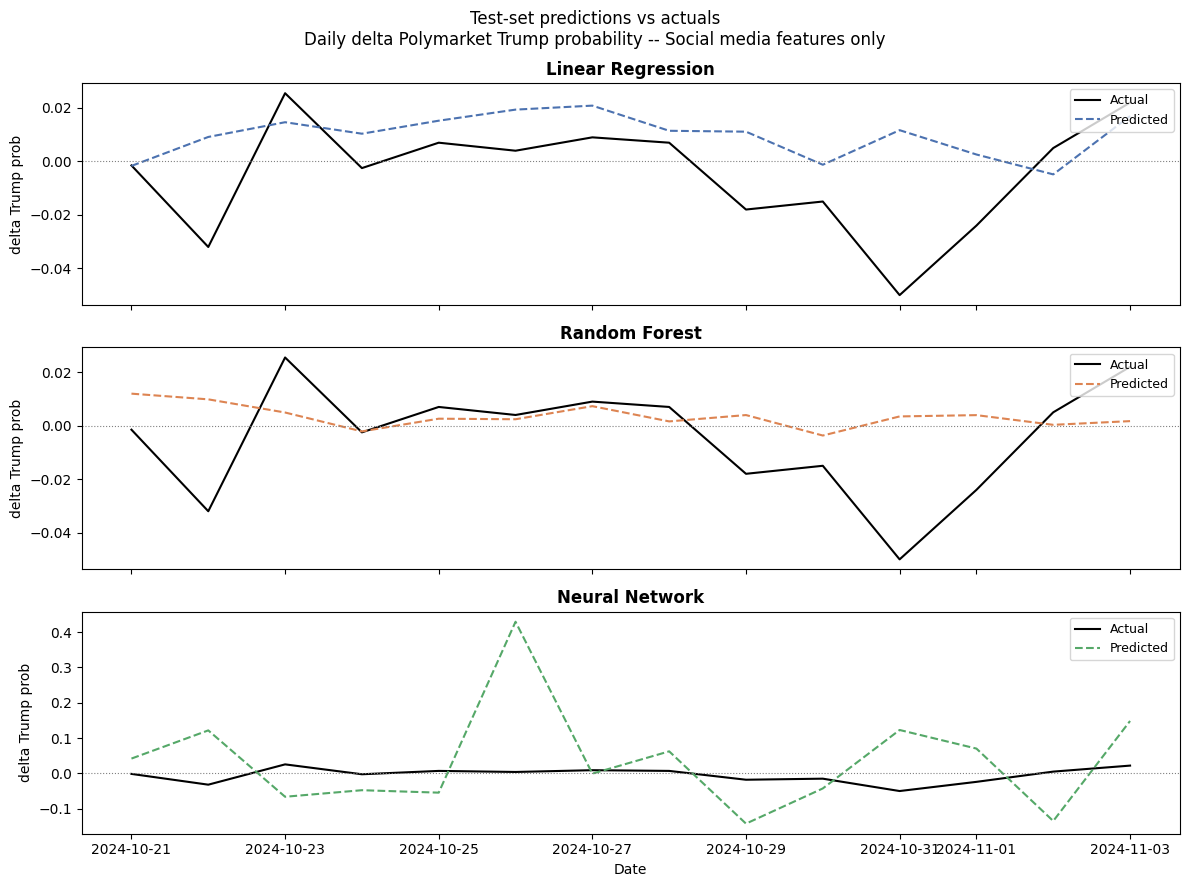

In [15]:
test_dates = df_test["date"].values
colors = ["#4C72B0", "#DD8452", "#55A868"]

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for ax, (label, pred, col) in zip(axes, [
    ("Linear Regression", lr_pred, colors[0]),
    ("Random Forest",     rf_pred, colors[1]),
    ("Neural Network",    nn_pred, colors[2]),
]):
    ax.plot(test_dates, y_test, label="Actual",    color="black", linewidth=1.5)
    ax.plot(test_dates, pred,   label="Predicted", color=col,    linewidth=1.5, linestyle="--")
    ax.axhline(0, color="grey", linewidth=0.8, linestyle=":")
    ax.set_title(label, fontweight="bold")
    ax.set_ylabel("delta Trump prob")
    ax.legend(loc="upper right", fontsize=9)
axes[-1].set_xlabel("Date")
fig.suptitle("Test-set predictions vs actuals\nDaily delta Polymarket Trump probability -- Social media features only", fontsize=12)
plt.tight_layout()
plt.show()

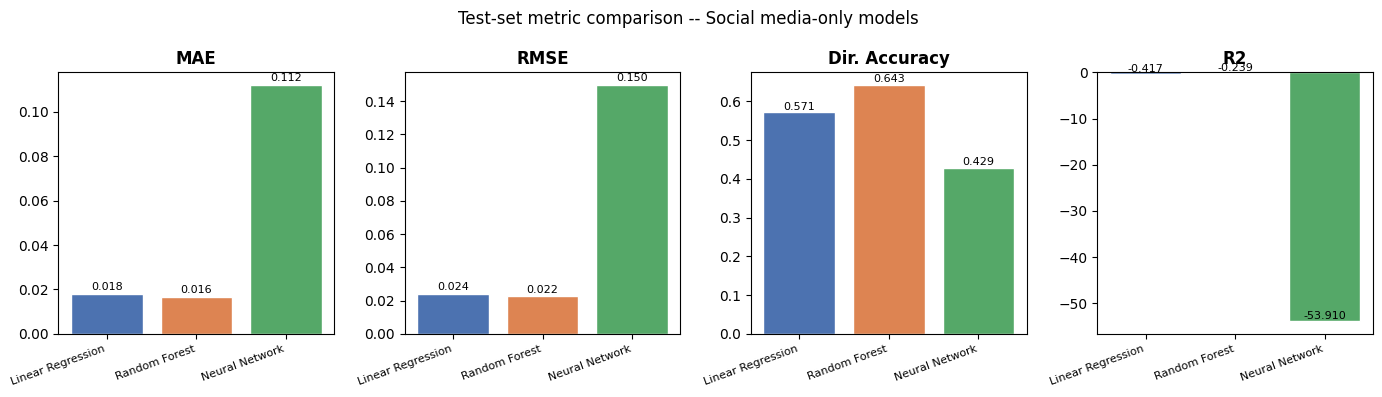

In [16]:
metrics = ["MAE", "RMSE", "Dir. Accuracy", "R2"]
models  = ["Linear Regression", "Random Forest", "Neural Network"]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, metric in zip(axes, metrics):
    vals = [test_summary.loc[m, metric] for m in models]
    bars = ax.bar(models, vals, color=colors, edgecolor="white")
    ax.set_title(metric, fontweight="bold")
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=20, ha="right", fontsize=8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)
fig.suptitle("Test-set metric comparison -- Social media-only models", fontsize=12)
plt.tight_layout()
plt.show()